## Selección del mejor modelo con AutoML

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Sexta etapa del proyecto. Busca el mejor modelo de machine learning para predecir
`chance_of_admit`, con la condición de que **supere al modelo base** establecido en
`05.Modelo-base` (MAE 0.0643).

La búsqueda se hace con **[FLAML](https://microsoft.github.io/FLAML/)**, la herramienta de
AutoML de Microsoft. Se eligió sobre las demás por dos motivos prácticos: es la más ligera
de instalar (no arrastra un entorno completo como AutoGluon ni reescribe el flujo de
trabajo como PyCaret) y está diseñada precisamente para dar buenos resultados con
presupuestos de cómputo pequeños, que es el caso aquí — 353 filas de entrenamiento.

Contenido:

1. Reutilización del pipeline de preprocesamiento de `4-feat_eng`.
2. Búsqueda automática con FLAML sobre cinco familias de modelos.
3. **Verificación independiente** del ganador con el mismo protocolo de validación
   cruzada de `05`, y comparación pareada contra alternativas.
4. Análisis de *overfitting* / *underfitting*, curvas de aprendizaje y escalabilidad.
5. Almacenamiento del pipeline de preprocesamiento + modelo en un único `.joblib`.

**Nota sobre el entorno:** FLAML necesita LightGBM y XGBoost, que a su vez requieren la
librería del sistema `libgomp1` (OpenMP). En Debian/Ubuntu:
`sudo apt-get install -y libgomp1`.

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from flaml import AutoML
from flaml.automl.data import get_output_from_log
from scipy import stats
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

# FLAML avisa de convergencias y de estimadores no disponibles; no aportan a la lectura
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

print(f"pandas {pd.__version__}")

pandas 3.0.5


## ⚙️ Configuración

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


RAIZ = buscar_raiz_proyecto()
sys.path.insert(0, str(RAIZ / "src"))

ARCHIVO_DATOS = RAIZ / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
ARCHIVO_PIPELINE = RAIZ / "data" / "06_models" / "pipeline_preprocesamiento.joblib"
ARCHIVO_METRICAS_BASE = RAIZ / "data" / "08_reporting" / "metricas_modelo_base.parquet"
DIR_MODELOS = RAIZ / "data" / "06_models"
DIR_REPORTES = RAIZ / "data" / "08_reporting"
ARCHIVO_LOG_BUSQUEDA = DIR_REPORTES / "flaml_busqueda.log"

TARGET = "chance_of_admit"
PROPORCION_TEST = 0.25
SEMILLA = 42
# presupuesto de la busqueda automatica, en segundos
PRESUPUESTO_SEGUNDOS = 180

sns.set_theme(style="whitegrid", palette="deep")
print(f"Presupuesto de busqueda: {PRESUPUESTO_SEGUNDOS} s")

Presupuesto de busqueda: 180 s


## 💾 Load data y partición

Se repite la misma partición de `4-feat_eng` y `5-models` (semilla 42, 25 % de prueba)
para que todas las métricas de este notebook sean directamente comparables con las del
modelo base.

In [3]:
df = pd.read_parquet(ARCHIVO_DATOS)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, random_state=SEMILLA
)
print(f"train: {X_train.shape[0]} filas   test: {X_test.shape[0]} filas")

metricas_base = pd.read_parquet(ARCHIVO_METRICAS_BASE).set_index("modelo")
print("\nReferencias a superar (MAE en test), registradas en 05-models:")
print(metricas_base[["MAE", "R2"]].round(4).to_string())

train: 353 filas   test: 118 filas

Referencias a superar (MAE en test), registradas en 05-models:
                                      MAE      R2
modelo                                           
1. dummy (media)                   0.1191 -0.0017
2. dummy (mediana)                 0.1192 -0.0002
3. heuristica de 03.3              0.0643  0.6667
4. regresion solo con cgpa         0.0501  0.7634
5. ridge 7 variables (referencia)  0.0485  0.7934


## 🔧 Pipeline de preprocesamiento

Se carga el artefacto de `4-feat_eng` y se clona para obtenerlo **sin ajustar**. FLAML
recibe la matriz ya transformada; el pipeline completo (preprocesamiento + modelo) se
reensambla al final para guardarlo como una sola pieza.

Hay una consecuencia metodológica que conviene explicitar: al transformar antes de la
búsqueda, el preprocesamiento se ajusta **una vez sobre todo el conjunto de
entrenamiento**, y la validación cruzada interna de FLAML trabaja sobre esa matriz. Es
una fuga pequeña —afecta a medianas de imputación y a la escala, no al target— y es el
compromiso estándar cuando se usa AutoML sobre datos tabulares. Por eso el ganador **se
vuelve a validar más abajo con el pipeline completo dentro de cada pliegue**, donde ya no
existe esa fuga.

In [4]:
preprocesador = clone(joblib.load(ARCHIVO_PIPELINE))

X_train_preparado = preprocesador.fit_transform(X_train, y_train)
X_test_preparado = preprocesador.transform(X_test)

print(f"X_train: {X_train.shape} -> {X_train_preparado.shape}")
X_train_preparado.head(3).round(3)

X_train: (353, 7) -> (353, 7)


,gre_score,toefl_score,sop,lor,cgpa,university_rating,research
94,-1.177,-1.386,-1.349,-1.052,-1.567,-0.095,0.0
287,0.676,1.075,1.602,1.161,0.847,1.629,1.0
369,-1.354,-1.550,-1.349,-0.498,-0.938,-1.820,1.0


## 🤖 Búsqueda automática con FLAML

FLAML no prueba combinaciones al azar ni recorre una rejilla: usa **CFO**
(*Cost-Frugal Optimization*), una búsqueda que tiene en cuenta el **costo** de cada
configuración. Empieza por modelos baratos y pequeños, y solo invierte tiempo en
configuraciones caras cuando la evidencia sugiere que valen la pena. Con presupuestos
pequeños suele llegar más lejos que una búsqueda aleatoria.

Configuración de la búsqueda:

| Parámetro | Valor | Por qué |
|---|---|---|
| `task` | `regression` | el target es continuo |
| `metric` | `mae` | la misma métrica principal que en todo el proyecto |
| `eval_method` | `cv`, 5 pliegues | validación cruzada interna, no una partición única |
| `time_budget` | 180 s | suficiente para varios cientos de configuraciones en un dataset de 353 filas |
| `estimator_list` | LightGBM, XGBoost, Random Forest, Extra Trees, XGBoost de profundidad limitada | cinco familias distintas, no variantes de la misma |

**Advertencia de reproducibilidad:** el criterio de parada es el tiempo, así que en una
máquina más rápida o más lenta la búsqueda explorará un número distinto de
configuraciones. El modelo ganador puede variar entre ejecuciones; por eso las
conclusiones de este notebook no se apoyan en la búsqueda en sí, sino en la
**verificación posterior con validación cruzada repetida**, que sí es determinista.

In [5]:
DIR_REPORTES.mkdir(parents=True, exist_ok=True)
buscador = AutoML()

inicio = time.time()
buscador.fit(
    X_train=X_train_preparado,
    y_train=y_train,
    task="regression",
    metric="mae",
    eval_method="cv",
    n_splits=5,
    time_budget=PRESUPUESTO_SEGUNDOS,
    estimator_list=["lgbm", "xgboost", "rf", "extra_tree", "xgb_limitdepth"],
    seed=SEMILLA,
    verbose=0,
    log_file_name=str(ARCHIVO_LOG_BUSQUEDA),
)
duracion = time.time() - inicio

print(f"Busqueda terminada en {duracion:.0f} s")
print(f"Mejor familia   : {buscador.best_estimator}")
print(f"Mejor MAE (cv)  : {buscador.best_loss:.5f}")
print(f"Configuracion   : {buscador.best_config}")
print(f"Tiempo del mejor ajuste: {buscador.best_config_train_time:.2f} s")

Busqueda terminada en 183 s
Mejor familia   : extra_tree
Mejor MAE (cv)  : 0.04465
Configuracion   : {'n_estimators': 60, 'max_features': np.float64(0.44793795207716336), 'max_leaves': 127}
Tiempo del mejor ajuste: 0.06 s


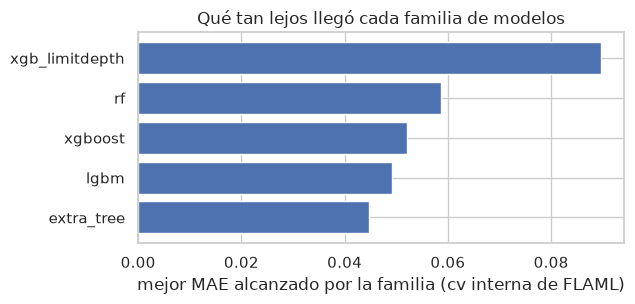

,mejor_MAE_cv
familia,
extra_tree,0.04465
lgbm,0.04912
xgboost,0.05209
rf,0.05857
xgb_limitdepth,0.08963


In [6]:
resumen_familias = (
    pd.DataFrame(
        [
            {"familia": familia, "mejor_MAE_cv": buscador.best_loss_per_estimator[familia]}
            for familia in buscador.estimator_list
        ]
    )
    .set_index("familia")
    .sort_values("mejor_MAE_cv")
)

_, ax = plt.subplots(figsize=(6.5, 3.2))
finitos = resumen_familias[np.isfinite(resumen_familias["mejor_MAE_cv"])]
ax.barh(finitos.index, finitos["mejor_MAE_cv"])
ax.set_xlabel("mejor MAE alcanzado por la familia (cv interna de FLAML)")
ax.set_title("Qué tan lejos llegó cada familia de modelos")
plt.tight_layout()
plt.show()

resumen_familias.round(5)

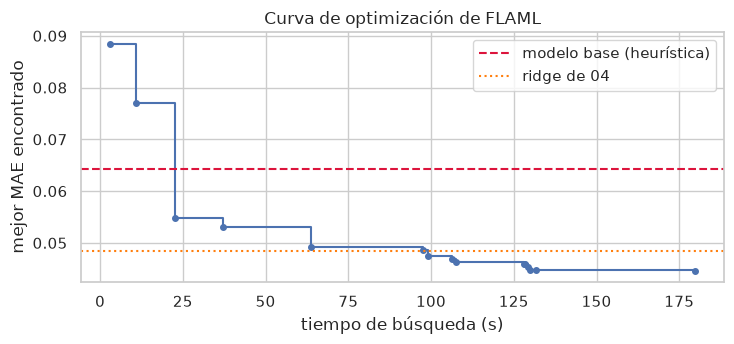

Configuraciones que mejoraron el récord: 15
MAE al primer segundo: 0.0885   al final: 0.0446


In [7]:
tiempos, mejor_valid, _, _, _ = get_output_from_log(
    filename=str(ARCHIVO_LOG_BUSQUEDA), time_budget=PRESUPUESTO_SEGUNDOS
)

_, ax = plt.subplots(figsize=(7.5, 3.6))
ax.step(
    tiempos,
    -np.array(mejor_valid) if mejor_valid[0] < 0 else mejor_valid,
    where="post",
    marker="o",
    markersize=4,
)
ax.axhline(
    metricas_base.loc["3. heuristica de 03.3", "MAE"],
    color="crimson",
    linestyle="--",
    label="modelo base (heurística)",
)
ax.axhline(
    metricas_base.loc["5. ridge 7 variables (referencia)", "MAE"],
    color="tab:orange",
    linestyle=":",
    label="ridge de 04",
)
ax.set_xlabel("tiempo de búsqueda (s)")
ax.set_ylabel("mejor MAE encontrado")
ax.set_title("Curva de optimización de FLAML")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Configuraciones que mejoraron el récord: {len(tiempos)}")
print(f"MAE al primer segundo: {mejor_valid[0]:.4f}   al final: {mejor_valid[-1]:.4f}")

## 🔬 Verificación independiente del ganador

La búsqueda entrega un modelo, pero su métrica viene de la validación interna de FLAML.
Para poder afirmar que **supera al modelo base** hay que medirlo con el mismo protocolo
que se usó en `05`: `RepeatedKFold` de 5 pliegues x 5 repeticiones, y con el pipeline
completo reajustándose dentro de cada pliegue.

Se comparan tres candidatos:

1. **El modelo elegido por el AutoML**, con los hiperparámetros que encontró.
2. **La misma familia con los hiperparámetros por defecto**, para responder a una
   pregunta incómoda: ¿el ajuste automático aportó algo, o el valor estaba en elegir la
   familia?
3. **La `Ridge` de `4-feat_eng`**, el mejor modelo lineal conocido.

Como los tres se evalúan sobre **exactamente los mismos 25 pliegues**, la comparación
puede hacerse **pareada**, que es mucho más sensible que comparar dos medias con sus
desviaciones: elimina la variabilidad debida a qué filas cayeron en cada pliegue.

In [8]:
modelo_automl = clone(buscador.model.estimator)
familia_por_defecto = type(modelo_automl)(random_state=SEMILLA)

CANDIDATOS = {
    "automl (ajustado por FLAML)": modelo_automl,
    "misma familia, por defecto": familia_por_defecto,
    "ridge (de 04-feat_eng)": Ridge(alpha=1.0),
}

validacion = RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEMILLA)
puntajes_validacion = {}
filas_verificacion = []
for nombre, estimador in CANDIDATOS.items():
    resultado = cross_validate(
        Pipeline([("preparacion", clone(preprocesador)), ("modelo", clone(estimador))]),
        X_train,
        y_train,
        cv=validacion,
        scoring=["neg_mean_absolute_error", "r2"],
        return_train_score=True,
        n_jobs=-1,
    )
    puntajes_validacion[nombre] = -resultado["test_neg_mean_absolute_error"]
    filas_verificacion.append(
        {
            "modelo": nombre,
            "MAE_validacion": -resultado["test_neg_mean_absolute_error"].mean(),
            "desv_est": resultado["test_neg_mean_absolute_error"].std(),
            "MAE_entrenamiento": -resultado["train_neg_mean_absolute_error"].mean(),
            "R2_validacion": resultado["test_r2"].mean(),
            "tiempo_fit_ms": 1000 * resultado["fit_time"].mean(),
        }
    )

verificacion = pd.DataFrame(filas_verificacion).set_index("modelo")
verificacion["brecha_train_validacion"] = (
    verificacion["MAE_validacion"] - verificacion["MAE_entrenamiento"]
)
verificacion.round(4)

,MAE_validacion,desv_est,MAE_entrenamiento,R2_validacion,tiempo_fit_ms,brecha_train_validacion
modelo,,,,,,
automl (ajustado por FLAML),0.0450,0.0040,0.0112,0.7977,651.8678,0.0337
"misma familia, por defecto",0.0445,0.0046,0.0000,0.7897,528.1277,0.0445
ridge (de 04-feat_eng),0.0468,0.0047,0.0456,0.7935,136.5945,0.0012


In [9]:
referencia = puntajes_validacion["automl (ajustado por FLAML)"]
filas_pareadas = []
for nombre, puntajes in puntajes_validacion.items():
    if nombre == "automl (ajustado por FLAML)":
        continue
    diferencias = puntajes - referencia
    estadistico, p_valor = stats.ttest_rel(puntajes, referencia)
    filas_pareadas.append(
        {
            "comparacion": f"{nombre} vs. automl",
            "diferencia_media_MAE": diferencias.mean(),
            "desv_est_diferencias": diferencias.std(),
            "t": estadistico,
            "p_valor": p_valor,
        }
    )

print("Diferencia positiva = el otro modelo tiene MAS error que el elegido por el AutoML")
pd.DataFrame(filas_pareadas).set_index("comparacion").round(4)

Diferencia positiva = el otro modelo tiene MAS error que el elegido por el AutoML


,diferencia_media_MAE,desv_est_diferencias,t,p_valor
comparacion,,,,
"misma familia, por defecto vs. automl",-0.0005,0.0017,-1.4797,0.1520
ridge (de 04-feat_eng) vs. automl,0.0018,0.0026,3.4419,0.0021


## 🔍 Overfitting y underfitting

La tabla anterior incluye el error en **entrenamiento** además del de validación, y la
diferencia entre ambos es el diagnóstico:

- **Brecha grande** → el modelo memoriza los datos que ve (alta varianza).
- **Brecha nula pero error alto en los dos** → el modelo es demasiado rígido para el
  problema (*underfitting*, alto sesgo).

Con modelos de árboles hay que leer esa brecha con cuidado: un bosque de árboles sin
podar memoriza el conjunto de entrenamiento **por construcción** (cada árbol puede aislar
cada fila), así que un error de entrenamiento cercano a cero no significa, por sí solo,
que el modelo esté roto. Lo que importa es si el error de **validación** se degrada.

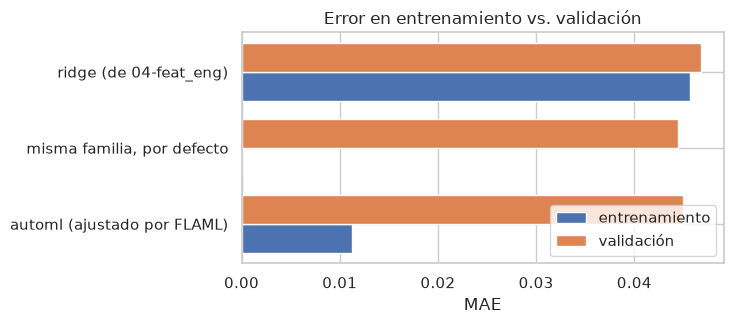

,MAE_entrenamiento,MAE_validacion,brecha_train_validacion
modelo,,,
automl (ajustado por FLAML),0.0112,0.0450,0.0337
"misma familia, por defecto",0.0000,0.0445,0.0445
ridge (de 04-feat_eng),0.0456,0.0468,0.0012


In [10]:
_, ax = plt.subplots(figsize=(7.5, 3.4))
posiciones = np.arange(len(verificacion))
ancho = 0.38
ax.barh(posiciones - ancho / 2, verificacion["MAE_entrenamiento"], ancho, label="entrenamiento")
ax.barh(posiciones + ancho / 2, verificacion["MAE_validacion"], ancho, label="validación")
ax.set_yticks(posiciones)
ax.set_yticklabels(verificacion.index)
ax.set_xlabel("MAE")
ax.set_title("Error en entrenamiento vs. validación")
ax.legend()
plt.tight_layout()
plt.show()

verificacion[["MAE_entrenamiento", "MAE_validacion", "brecha_train_validacion"]].round(4)

## 📈 Curvas de aprendizaje y escalabilidad

Las mismas tres vistas que en `05-models`, ahora para el modelo elegido y para la `Ridge`
como contraste: error frente a número de muestras, tiempo de ajuste frente a número de
muestras, y error frente a tiempo de ajuste.

In [11]:
TALLAS = np.linspace(0.1, 1.0, 8)
MODELOS_CURVA = {
    "automl (extra trees)": Pipeline(
        [("preparacion", clone(preprocesador)), ("modelo", clone(modelo_automl))]
    ),
    "ridge (de 04)": Pipeline(
        [("preparacion", clone(preprocesador)), ("modelo", Ridge(alpha=1.0))]
    ),
}


def curva_de_aprendizaje(modelo) -> dict:
    """Ejecuta learning_curve devolviendo MAE de train/validación y tiempos de ajuste."""
    tallas, puntaje_train, puntaje_validacion, tiempos_fit, _ = learning_curve(
        modelo,
        X_train,
        y_train,
        train_sizes=TALLAS,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEMILLA),
        scoring="neg_mean_absolute_error",
        return_times=True,
        n_jobs=-1,
    )
    return {
        "tallas": tallas,
        "mae_train": -puntaje_train.mean(axis=1),
        "mae_validacion": -puntaje_validacion.mean(axis=1),
        "desv_validacion": puntaje_validacion.std(axis=1),
        "tiempo_fit": tiempos_fit.mean(axis=1),
    }


curvas = {nombre: curva_de_aprendizaje(modelo) for nombre, modelo in MODELOS_CURVA.items()}

mae_por_talla = pd.DataFrame(
    {nombre: curva["mae_validacion"] for nombre, curva in curvas.items()},
    index=pd.Index(next(iter(curvas.values()))["tallas"], name="muestras_entrenamiento"),
)
print("MAE de validación según el número de muestras:")
mae_por_talla.round(4)

MAE de validación según el número de muestras:


,automl (extra trees),ridge (de 04)
muestras_entrenamiento,,
28,0.0561,0.0556
64,0.0527,0.0500
100,0.0522,0.0485
136,0.0506,0.0474
173,0.0509,0.0476
209,0.0477,0.0479
245,0.0454,0.0472
282,0.0438,0.0464


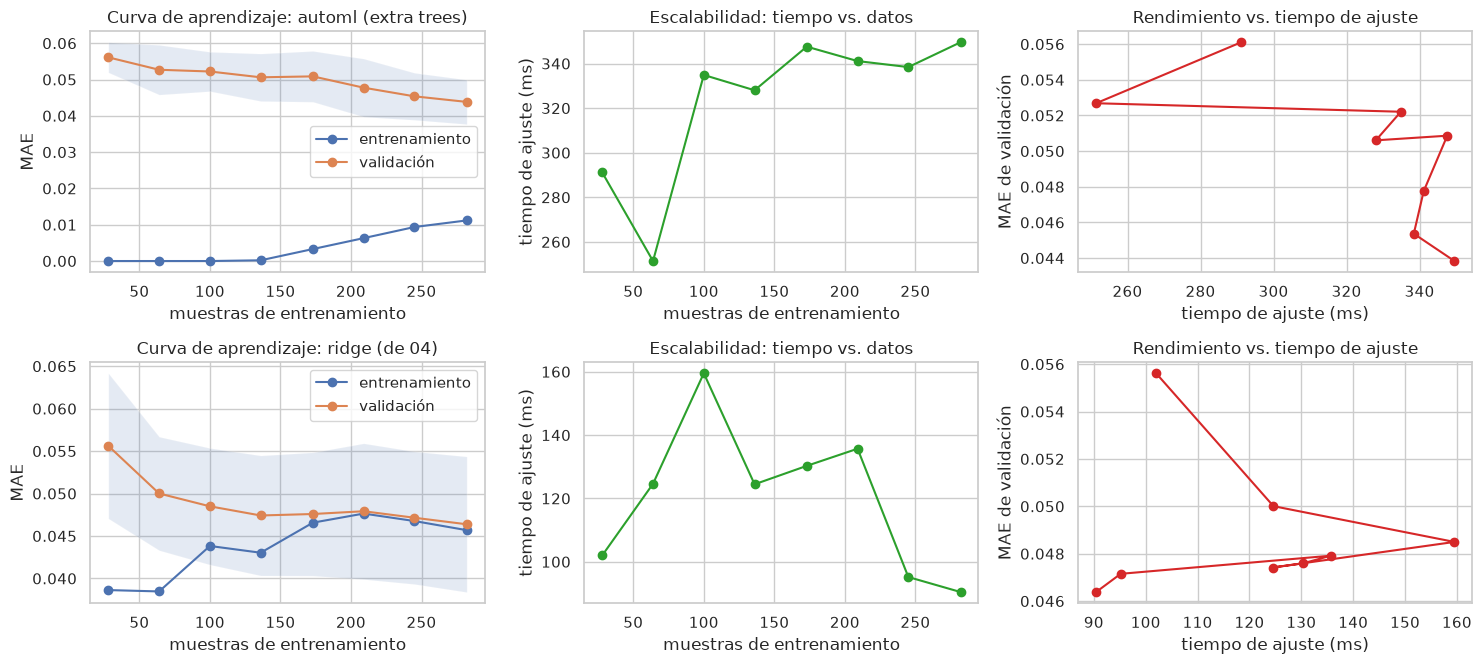

In [12]:
figura, axes = plt.subplots(len(curvas), 3, figsize=(15, 3.4 * len(curvas)))
for fila, (nombre, curva) in enumerate(curvas.items()):
    ax_error, ax_tiempo, ax_escala = axes[fila]

    ax_error.plot(curva["tallas"], curva["mae_train"], "o-", label="entrenamiento")
    ax_error.plot(curva["tallas"], curva["mae_validacion"], "o-", label="validación")
    ax_error.fill_between(
        curva["tallas"],
        curva["mae_validacion"] - curva["desv_validacion"],
        curva["mae_validacion"] + curva["desv_validacion"],
        alpha=0.15,
    )
    ax_error.set_xlabel("muestras de entrenamiento")
    ax_error.set_ylabel("MAE")
    ax_error.set_title(f"Curva de aprendizaje: {nombre}")
    ax_error.legend()

    ax_tiempo.plot(curva["tallas"], 1000 * curva["tiempo_fit"], "o-", color="tab:green")
    ax_tiempo.set_xlabel("muestras de entrenamiento")
    ax_tiempo.set_ylabel("tiempo de ajuste (ms)")
    ax_tiempo.set_title("Escalabilidad: tiempo vs. datos")

    ax_escala.plot(1000 * curva["tiempo_fit"], curva["mae_validacion"], "o-", color="tab:red")
    ax_escala.set_xlabel("tiempo de ajuste (ms)")
    ax_escala.set_ylabel("MAE de validación")
    ax_escala.set_title("Rendimiento vs. tiempo de ajuste")

plt.tight_layout()
plt.show()

## 🏁 Evaluación final sobre el conjunto de prueba

Con el modelo ya elegido mediante validación cruzada, se mide **una sola vez** sobre el
conjunto de prueba y se compara con las referencias registradas en `05-models`.

In [13]:
modelo_final = Pipeline([("preparacion", clone(preprocesador)), ("modelo", clone(modelo_automl))])
modelo_final.fit(X_train, y_train)
prediccion_final = modelo_final.predict(X_test)

filas_test = [
    {
        "modelo": "automl (modelo final)",
        "MAE": mean_absolute_error(y_test, prediccion_final),
        "RMSE": root_mean_squared_error(y_test, prediccion_final),
        "R2": r2_score(y_test, prediccion_final),
        "MAPE": mean_absolute_percentage_error(y_test, prediccion_final),
    }
]
for nombre, estimador in list(CANDIDATOS.items())[1:]:
    ajustado = Pipeline([("preparacion", clone(preprocesador)), ("modelo", clone(estimador))]).fit(
        X_train, y_train
    )
    prediccion = ajustado.predict(X_test)
    filas_test.append(
        {
            "modelo": nombre,
            "MAE": mean_absolute_error(y_test, prediccion),
            "RMSE": root_mean_squared_error(y_test, prediccion),
            "R2": r2_score(y_test, prediccion),
            "MAPE": mean_absolute_percentage_error(y_test, prediccion),
        }
    )

comparacion_test = pd.concat(
    [pd.DataFrame(filas_test).set_index("modelo"), metricas_base[["MAE", "RMSE", "R2", "MAPE"]]]
)
mae_base = metricas_base.loc["3. heuristica de 03.3", "MAE"]
comparacion_test["mejora_vs_modelo_base_%"] = 100 * (mae_base - comparacion_test["MAE"]) / mae_base
comparacion_test.sort_values("MAE").round(4)

,MAE,RMSE,R2,MAPE,mejora_vs_modelo_base_%
modelo,,,,,
"misma familia, por defecto",0.0467,0.0659,0.7977,0.0734,27.3676
automl (modelo final),0.0476,0.0647,0.8048,0.0747,25.9232
ridge (de 04-feat_eng),0.0485,0.0666,0.7934,0.0781,24.5205
5. ridge 7 variables (referencia),0.0485,0.0666,0.7934,0.0781,24.5205
4. regresion solo con cgpa,0.0501,0.0712,0.7634,0.0802,22.0490
3. heuristica de 03.3,0.0643,0.0845,0.6667,0.1037,0.0000
1. dummy (media),0.1191,0.1465,-0.0017,0.1799,-85.3723
2. dummy (mediana),0.1192,0.1464,-0.0002,0.1821,-85.5808


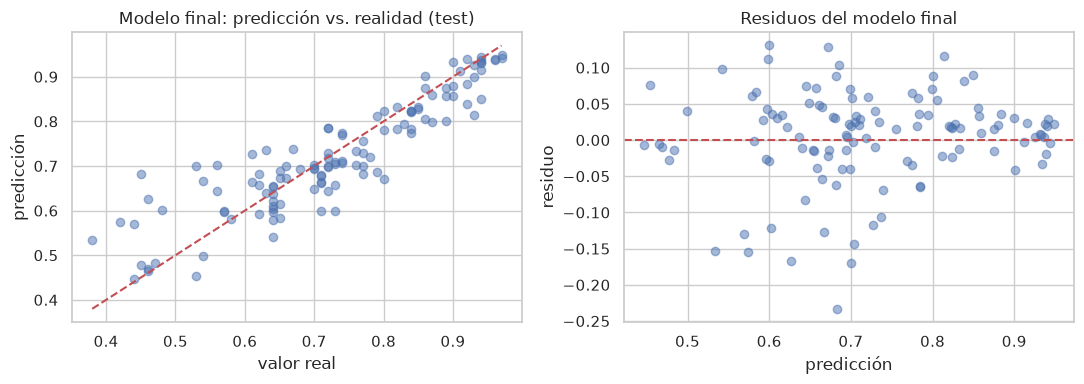

Residuo medio por tercil (positivo = el modelo subestima):
                   mean  count
chance_of_admit               
target bajo     -0.0387     40
target medio     0.0246     40
target alto      0.0261     38


In [14]:
residuos = y_test - prediccion_final

_, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, prediccion_final, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("valor real")
axes[0].set_ylabel("predicción")
axes[0].set_title("Modelo final: predicción vs. realidad (test)")

axes[1].scatter(prediccion_final, residuos, alpha=0.5)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("predicción")
axes[1].set_ylabel("residuo")
axes[1].set_title("Residuos del modelo final")
plt.tight_layout()
plt.show()

tercil = pd.qcut(y_test, 3, labels=["target bajo", "target medio", "target alto"])
print("Residuo medio por tercil (positivo = el modelo subestima):")
print(residuos.groupby(tercil, observed=True).agg(["mean", "count"]).round(4).to_string())

## 💾 Almacenar el pipeline de preprocesamiento + modelo

Se guarda **una sola pieza** que contiene el preprocesamiento y el modelo. Es lo que
permite que `7-deploy` reciba los datos crudos de un aspirante y obtenga una predicción
sin repetir ninguna transformación a mano — y lo que garantiza que no haya diferencias
entre lo que se hizo al entrenar y lo que ocurre en producción.

In [15]:
ARCHIVO_MODELO_FINAL = DIR_MODELOS / "modelo_final_automl.joblib"
joblib.dump(modelo_final, ARCHIVO_MODELO_FINAL)

metricas_finales = comparacion_test.copy()
metricas_finales.reset_index().to_parquet(
    DIR_REPORTES / "metricas_modelo_final.parquet", index=False
)

print(
    f"modelo -> {ARCHIVO_MODELO_FINAL.relative_to(RAIZ)} ({ARCHIVO_MODELO_FINAL.stat().st_size / 1024:.1f} KB)"
)
print(f"metricas -> {(DIR_REPORTES / 'metricas_modelo_final.parquet').relative_to(RAIZ)}")

recargado = joblib.load(ARCHIVO_MODELO_FINAL)
if not np.allclose(recargado.predict(X_test), prediccion_final):
    raise ValueError("El modelo recargado no reproduce las mismas predicciones")
print("\nEl modelo recargado reproduce las mismas predicciones.")

aspirante = pd.DataFrame(
    [
        {
            "gre_score": 325,
            "toefl_score": 113,
            "university_rating": 4,
            "sop": 4.5,
            "lor": None,
            "cgpa": 9.1,
            "research": True,
        }
    ]
)
print(
    f"Prediccion para un aspirante nuevo (con un dato faltante): {recargado.predict(aspirante)[0]:.3f}"
)

modelo -> data/06_models/modelo_final_automl.joblib (1097.8 KB)
metricas -> data/08_reporting/metricas_modelo_final.parquet



El modelo recargado reproduce las mismas predicciones.
Prediccion para un aspirante nuevo (con un dato faltante): 0.836


## 📊 Analysis of Results and Conclusions

### La búsqueda

FLAML probó configuraciones de cinco familias durante 180 segundos y mejoró el récord 15
veces, bajando de un MAE de 0.0885 en el primer segundo a **0.04465**. El ganador fue
**Extra Trees** con 60 árboles, `max_features = 0.45` y `max_leaves = 127`.

El orden entre familias es informativo por sí mismo:

| Familia | Mejor MAE (cv interna de FLAML) |
|---|---|
| Extra Trees | **0.04465** |
| LightGBM | 0.04912 |
| XGBoost | 0.05209 |
| Random Forest | 0.05857 |
| XGBoost de profundidad limitada | 0.08963 |

Los métodos de *boosting* —los que suelen ganar en datos tabulares— quedaron por detrás
de un ensamble de árboles aleatorizados. Con 353 filas de entrenamiento tiene sentido: el
*boosting* ajusta los errores residuales de forma secuencial y necesita más datos para no
sobreajustar, mientras que Extra Trees promedia árboles muy aleatorizados, lo que reduce
la varianza justo donde este dataset es débil.

### Verificación independiente: qué aportó realmente el AutoML

Medido con el protocolo de `05-models` (RepeatedKFold 5x5, pipeline completo dentro de
cada pliegue):

| Modelo | MAE validación | MAE entrenamiento | Brecha | R² | Tiempo ajuste |
|---|---|---|---|---|---|
| automl (ajustado por FLAML) | 0.0450 ± 0.0040 | 0.0112 | 0.0337 | 0.798 | 652 ms |
| misma familia, por defecto | 0.0445 ± 0.0046 | 0.0000 | 0.0445 | 0.790 | 528 ms |
| ridge (de `04-feat_eng`) | 0.0468 ± 0.0047 | 0.0456 | 0.0012 | 0.794 | 137 ms |

Las comparaciones **pareadas** sobre los mismos 25 pliegues son las que permiten
concluir algo:

- **Contra `Ridge`: +0.0018 de MAE a favor del AutoML (p = 0.002).** La mejora es real, no
  ruido de partición. Pero es pequeña: un 4 % relativo.
- **Contra la misma familia con hiperparámetros por defecto: −0.0005 (p = 0.15).**
  Empate estadístico.

Esa segunda línea es el hallazgo importante: **el valor del AutoML estuvo en elegir la
familia de modelos, no en ajustar sus hiperparámetros.** Un `ExtraTreesRegressor()` sacado
de la caja iguala a la configuración que FLAML encontró en tres minutos de búsqueda. Lo
que no era evidente de antemano —y donde sí hubo ganancia— es que Extra Trees superara a
LightGBM y XGBoost en este dataset.

### Overfitting y underfitting

| Modelo | Diagnóstico |
|---|---|
| `Ridge` | Brecha de 0.0012: no memoriza nada. Su error de validación (0.0468) y el de entrenamiento (0.0456) son casi iguales — el clásico perfil de **alto sesgo**, un modelo rígido para el problema |
| Extra Trees por defecto | MAE de entrenamiento **exactamente 0.0000**: memoriza cada fila del conjunto de entrenamiento |
| Extra Trees ajustado | MAE de entrenamiento 0.0112 y brecha de 0.0337 |

El árbol que memoriza perfectamente **no** es un modelo roto: es lo que hace por
construcción un bosque sin podar, y su error de validación sigue siendo el mejor de los
tres. La brecha mide capacidad de memorización, no daño. Lo relevante es que el error de
validación no se degrada.

Aun así, la configuración de FLAML (`max_leaves = 127`, `max_features = 0.45`) **sí limita
la memorización**: pasa de 0.0000 a 0.0112 de error en entrenamiento sin perder desempeño
en validación. Es un argumento para preferirla sobre los valores por defecto aunque las
métricas empaten: el mismo resultado con menos capacidad de sobreajuste es un modelo más
robusto ante datos nuevos.

### Curvas de aprendizaje: una conclusión que corrige a `05-models`

| Muestras | automl (extra trees) | ridge |
|---|---|---|
| 28 | 0.0561 | 0.0556 |
| 136 | 0.0506 | 0.0474 |
| 209 | 0.0477 | 0.0479 |
| 282 | **0.0438** | 0.0464 |

En `05-models` se concluyó, con la `Ridge`, que la curva de validación estaba plana y que
**más datos no ayudarían**. Con un modelo de mayor capacidad el diagnóstico cambia: la
curva del Extra Trees **sigue bajando en el último punto** (0.0454 → 0.0438 entre 245 y
282 muestras) y todavía no se ha aplanado.

La lectura correcta es que aquella conclusión era válida *para un modelo lineal*: la
`Ridge` satura pronto porque no tiene capacidad para aprovechar más ejemplos. El modelo
de árboles sí la tiene, y **con más datos su ventaja debería crecer**. Es un cambio
concreto en la recomendación de la etapa anterior.

**Escalabilidad:** el modelo final tarda 652 ms en ajustarse frente a 137 ms de la
`Ridge`, y ocupa 1.1 MB frente a los 8 coeficientes de un modelo lineal. En términos
absolutos ambos son irrelevantes a esta escala, pero la proporción (5x en tiempo, tres
órdenes de magnitud en tamaño) sí importa si el modelo se reentrena con frecuencia o se
despliega en un entorno con restricciones.

### Resultados en el conjunto de prueba

| Modelo | MAE | RMSE | R² | MAPE | Mejora vs. modelo base |
|---|---|---|---|---|---|
| misma familia, por defecto | 0.0467 | 0.0659 | 0.798 | 7.3 % | 27.4 % |
| **automl (modelo final)** | **0.0476** | **0.0647** | **0.805** | 7.5 % | **25.9 %** |
| ridge (de `04-feat_eng`) | 0.0485 | 0.0666 | 0.793 | 7.8 % | 24.5 % |
| regresión solo con `cgpa` | 0.0501 | 0.0712 | 0.763 | 8.0 % | 22.1 % |
| modelo base (heurística) | 0.0643 | 0.0845 | 0.667 | 10.4 % | — |
| dummy (media) | 0.1191 | 0.1465 | −0.002 | 18.0 % | −85 % |

**El objetivo se cumple: el modelo seleccionado supera al modelo base con holgura** —
MAE 26 % menor, R² de 0.667 a 0.805 — y también supera el listón exigente que fijaba
`05-models` (MAE < 0.0501, el de la regresión de una sola variable).

Merece señalarse que en test el modelo final tiene **el mejor RMSE (0.0647) y el mejor R²
(0.805) de todos**, aunque su MAE quede una milésima por encima del de la variante por
defecto. Con 118 filas de prueba, esa diferencia de 0.0009 en MAE está muy por debajo de
la desviación entre pliegues (±0.004): son el mismo modelo a efectos prácticos, y la
elección entre ambos se apoya en el argumento de capacidad de la sección anterior, no en
el decimal.

**El sesgo por tramos se reduce a la mitad** respecto al modelo base: el error medio en el
tercil bajo pasa de −0.076 a −0.039, y en el alto de +0.037 a +0.026. Sigue existiendo —
el modelo empuja hacia el centro— pero es menos pronunciado.

## 🎯 Recomendaciones

1. **Desplegar el modelo final, pero decidir conscientemente frente a `Ridge`.** La ventaja
   del Extra Trees sobre el modelo lineal es estadísticamente real (p = 0.002) y pequeña
   (0.0018 de MAE, 4 %). A cambio cuesta 5x más tiempo de ajuste, 1.1 MB frente a unos
   pocos bytes, y pierde la interpretabilidad directa de unos coeficientes. Si el producto
   necesita explicar *por qué* le dio ese número a un aspirante, `Ridge` sigue siendo una
   opción defendible; si prima la precisión, el modelo final.
2. **Recolectar más datos ahora sí rinde.** La curva de aprendizaje del modelo elegido
   sigue bajando en el último punto. Es una corrección a la recomendación de `05-models`,
   que se apoyaba en un modelo lineal ya saturado.
3. **Volver a lanzar la búsqueda cuando el dataset crezca**, con más presupuesto y sin
   restringir la lista de familias. El orden entre familias puede cambiar con más datos:
   el *boosting* suele adelantar a los ensambles aleatorizados a medida que hay más
   ejemplos.
4. **Mantener la verificación independiente como criterio de aceptación.** La métrica que
   reporta el AutoML sale de su validación interna, sobre una matriz preprocesada una sola
   vez. Ningún modelo debería aceptarse por ese número: hay que reevaluarlo con el
   pipeline completo dentro de cada pliegue, como se hizo aquí.
5. **Fijar la configuración encontrada en el código, no repetir la búsqueda en producción.**
   El presupuesto por tiempo hace que la búsqueda no sea reproducible entre máquinas. El
   artefacto guardado ya congela los hiperparámetros; la búsqueda es una herramienta de
   exploración, no un paso del pipeline de despliegue.
6. **Vigilar el sesgo en el tramo bajo.** Es donde el modelo más se equivoca (−0.039 de
   media) y donde un error tiene consecuencias reales: decirle a un aspirante que tiene más
   posibilidades de las que tiene. Conviene reportar el MAE por tramos, no solo el global.
7. **No esperar mucho más de este dataset.** Entre la heurística (0.0643) y el mejor modelo
   (0.0476) hay 0.017 de MAE; entre el mejor modelo y el error irreducible probablemente
   quede muy poco, porque las siete variables miden un mismo rasgo latente
   (`3-analysis`). El siguiente salto vendrá de variables nuevas, no de modelos mejores.

## 💡 Propuestas e ideas

- **Ensamblar `Ridge` y Extra Trees** (*stacking* o promedio simple): sus errores tienen
  perfiles distintos —uno con sesgo alto y varianza baja, el otro al revés—, que es la
  condición para que combinarlos ayude.
- **Estimar intervalos de predicción**, no solo el valor. Un bosque puede dar la dispersión
  entre árboles, y para un producto de orientación decir "entre 0.72 y 0.84" es más honesto
  y más útil que un 0.78 seco.
- **Pasar a `6-interpretation`** con este modelo: valores SHAP e importancia por permutación
  para explicar predicciones individuales, que es lo que exige un producto que aconseja a
  personas.
- **Evaluar con la métrica de ranking** (Spearman, acierto de cesta *segura / probable /
  ambiciosa*) antes de dar por cerrada la selección: el modelo se eligió optimizando MAE, y
  el uso real del producto es ordenar universidades.
- **Registrar cada búsqueda con MLflow** cuando el proyecto tenga más iteraciones, para
  poder comparar ejecuciones de AutoML entre sí en vez de fiarse del último resultado.

## 📖 References

- FLAML, *A Fast Library for AutoML & Tuning*: <https://microsoft.github.io/FLAML/>
- CFO, la búsqueda económica que usa FLAML:
  <https://microsoft.github.io/FLAML/docs/Use-Cases/Task-Oriented-AutoML>
- Curvas de aprendizaje en scikit-learn:
  <https://scikit-learn.org/stable/modules/learning_curve.html>
- `ExtraTreesRegressor`:
  <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html>
- Modelo base y criterio de aceptación: `notebooks/5-models/05.Modelo-base-BER-2026-08-21.ipynb`